In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

from imblearn.over_sampling import SMOTE

In [8]:
df = pd.read_csv("/content/HR-Employee-Attrition.csv")

In [9]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [10]:
print(df.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [12]:
print(df.describe())

               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335            

In [13]:
#Handiling the Missing Values
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [14]:
#Remove duplicates
df.drop_duplicates(inplace=True)

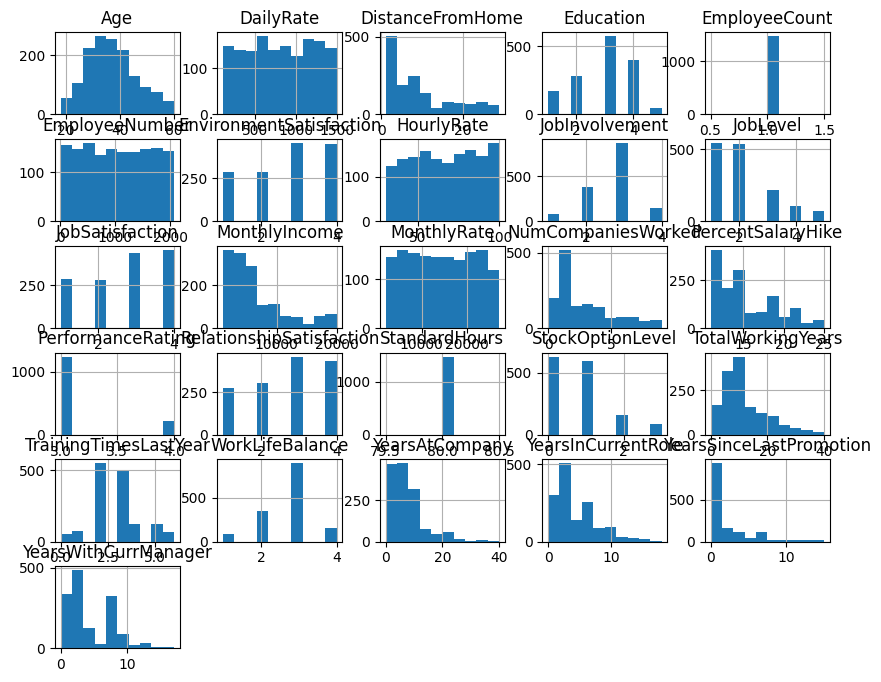

In [16]:
# Analysis of Univariate Analysis
# Numerical
df.hist(figsize=(10,8))
plt.show()




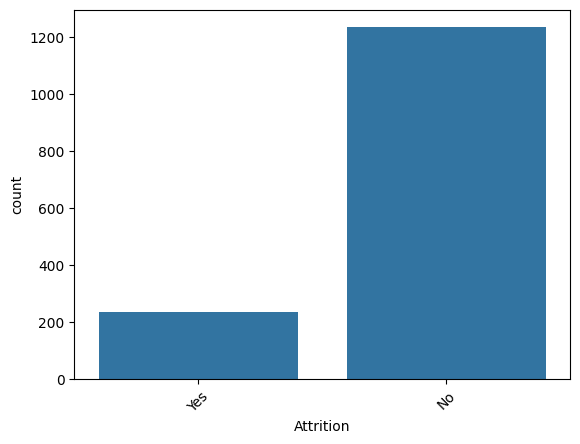

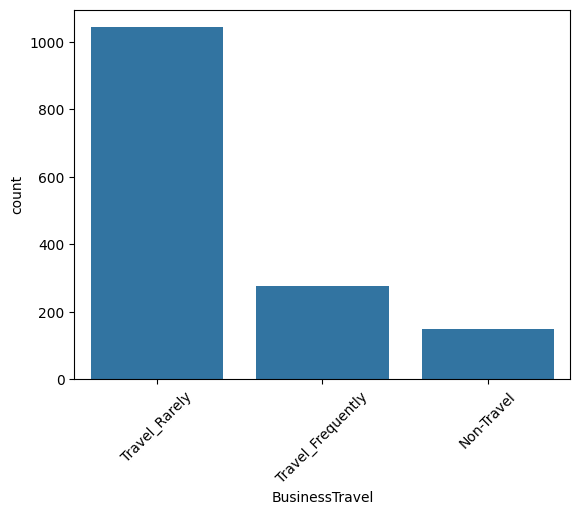

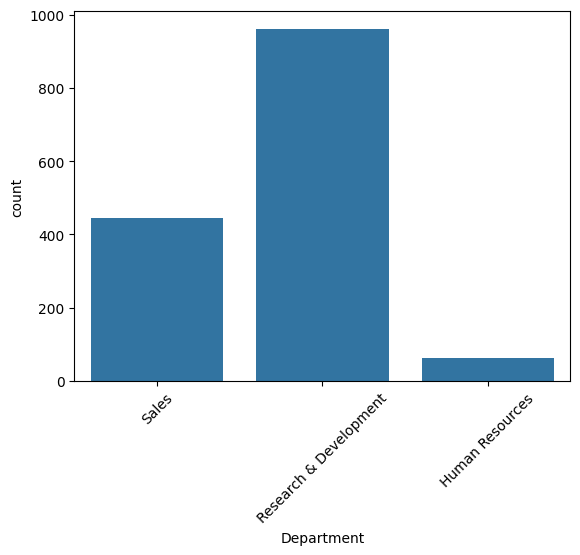

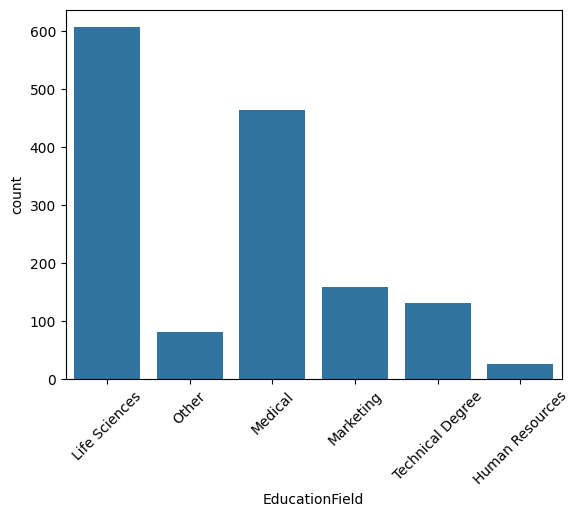

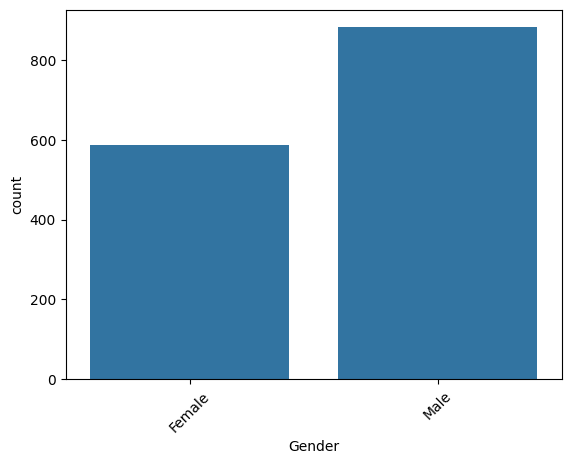

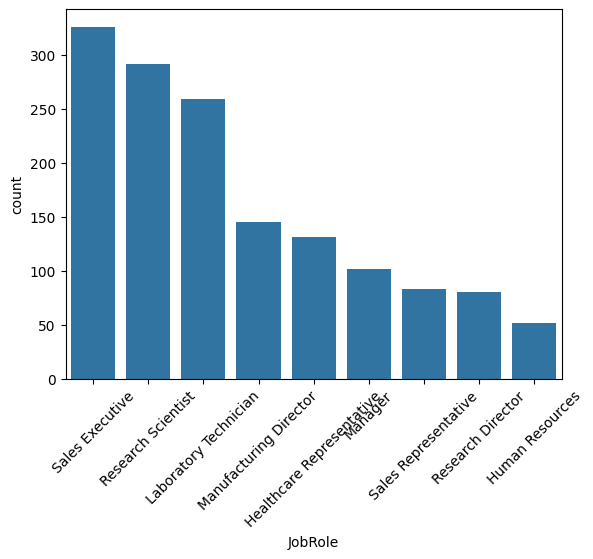

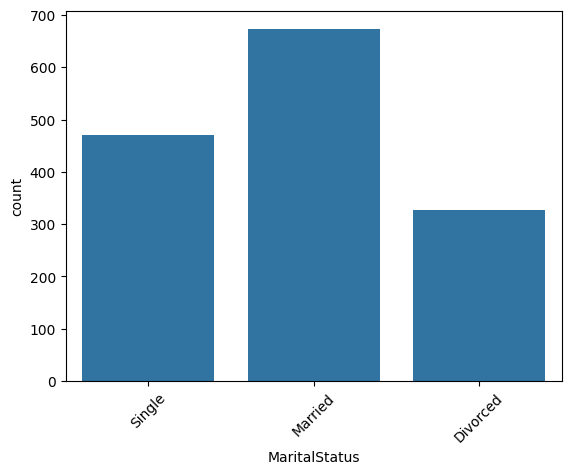

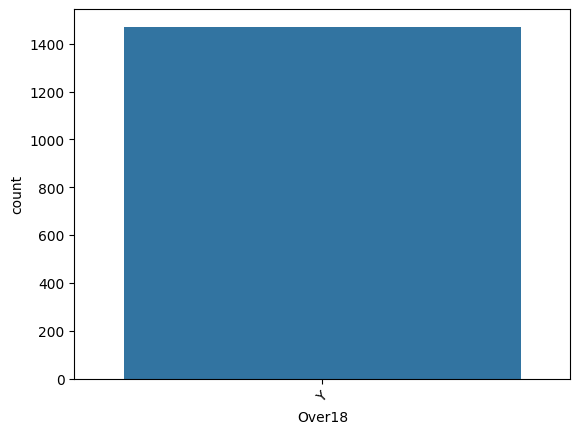

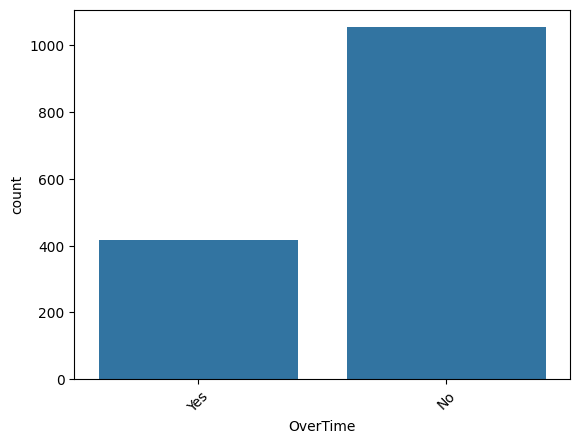

In [17]:
# Categorical
for col in df.select_dtypes(include='object'):
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.show()

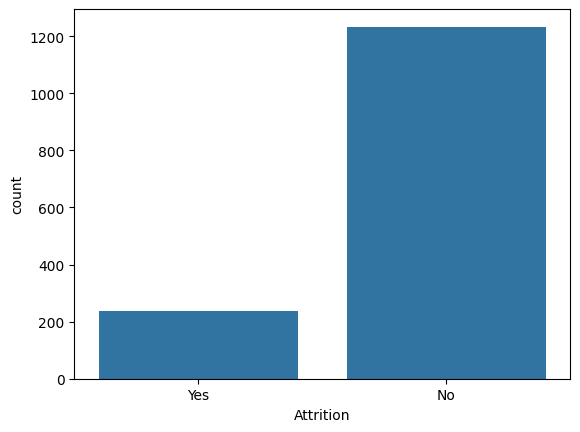

In [19]:
# Analysing Bivariates
sns.countplot(x='Attrition', data=df)
plt.show()

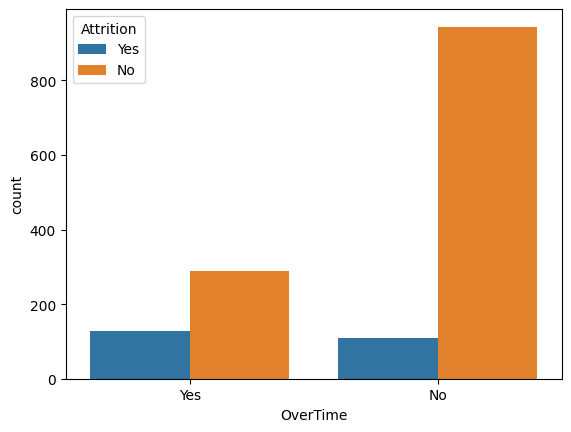

In [20]:
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.show()

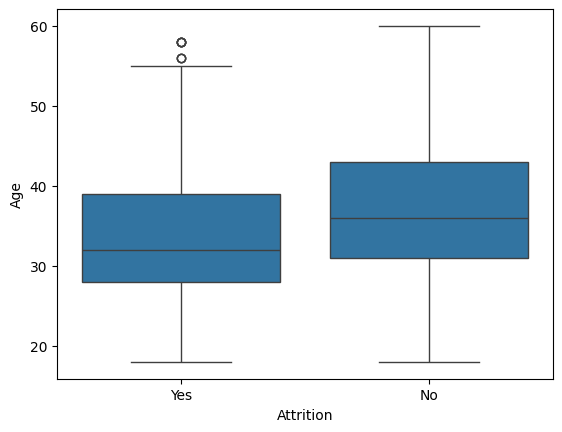

In [21]:
sns.boxplot(x='Attrition', y='Age', data=df)
plt.show()

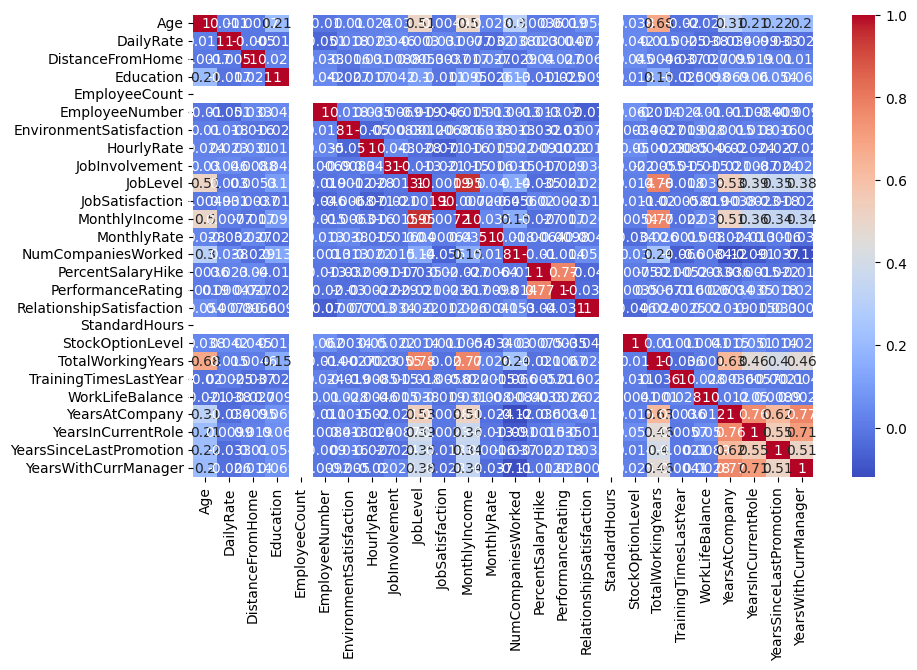

In [22]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
#Outlier Handling
# I skip heavy outlier removal to avoid confusion

In [23]:
# Encoding
# Convert target
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [24]:
#Scaling
X = df.drop('Attrition', axis=1)
y = df['Attrition']

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [25]:
#spliting the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [26]:
#SMOTE (Balance Data)
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

In [36]:
#Train the Model
models = {
      "Logistic Regression": LogisticRegression(),
      "Decision Tree": DecisionTreeClassifier(),
      "Random Forest": RandomForestClassifier(),
      "K-Nearest Neighbors": KNeighborsClassifier()
}

results = {}
for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)


  results[name] = {
      accuracy_score(y_test, y_pred),
      precision_score(y_test, y_pred),
      recall_score(y_test, y_pred),
      f1_score(y_test, y_pred),
      roc_auc_score(y_test, y_pred)
  }

In [28]:
#Evalution
results_df = pd.DataFrame(results, index=["Accuracy","Precision","Recall","F1","ROC-AUC"]).T
print(results_df)

                     Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.748299   0.314607  0.682927  0.430769  0.720910
Decision Tree        0.795918   0.320755  0.414634  0.361702  0.636171
Random Forest        0.877551   0.619048  0.317073  0.419355  0.642726
K-Nearest Neighbors  0.629252   0.201754  0.560976  0.296774  0.600646


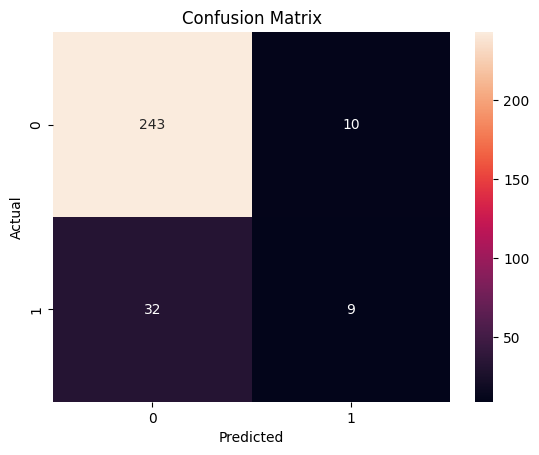

In [42]:
#Confusion Matrix
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [43]:
#Cross Validation
for name, model in models.items():
    score = cross_val_score(model, X, y, cv=5).mean()
    print(name, "CV Score:", score)



Logistic Regression CV Score: 0.8693877551020407
Decision Tree CV Score: 0.7836734693877551
Random Forest CV Score: 0.8537414965986395
K-Nearest Neighbors CV Score: 0.84421768707483


In [44]:
#Hyperparameter Tuning
param_grid = {
    'n_estimators': [50,100],
    'max_depth': [5,10,None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 100}


In [45]:
#comparing the models
print(results_df.sort_values(by='F1', ascending=False))

                     Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.748299   0.314607  0.682927  0.430769  0.720910
Random Forest        0.877551   0.619048  0.317073  0.419355  0.642726
Decision Tree        0.795918   0.320755  0.414634  0.361702  0.636171
K-Nearest Neighbors  0.629252   0.201754  0.560976  0.296774  0.600646


“I performed data preprocessing, EDA, encoding, scaling, handled imbalance using SMOTE, trained multiple models, evaluated them, and optimized using GridSearchCV